In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Tạo thư mục để lưu các biểu đồ nếu chưa tồn tại
PLOTS_DIR = 'plots_6_12_2025_1'
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f"Thư mục '{PLOTS_DIR}' đã sẵn sàng để lưu biểu đồ.")
# Cài đặt cấu hình chung cho các biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12
# Tải dữ liệu vào DataFrame
try:
    df = pd.read_csv('data_points/generated_student_data_v3.csv')
    print("Tải dữ liệu thành công!")
    print("5 dòng dữ liệu đầu tiên:")
    display(df.head())
except FileNotFoundError:
    print("Lỗi: Không tìm thấy file 'generated_student_data_v3.csv'.")
    df = None

Thư mục 'plots_6_12_2025_1' đã sẵn sàng để lưu biểu đồ.
Tải dữ liệu thành công!
5 dòng dữ liệu đầu tiên:


,Mã SV,Kỳ,Kỳ số,Năm,Mã Môn,Tên Môn,Hình Thức,Số ĐVHT,Loại ĐVHT,last_score,...,GPA Kỳ Hiện Tại,GPA Tích Lũy (sau kỳ này),Số môn trước đó,Tín chỉ tích lũy trước đó,Thời Gian Học Một Tuần,Thời Gian Làm Thêm,Hỗ Trợ Tài Chính,Hỗ Trợ Tinh Thần,Xung Đột Dữ Liệu,Hợp Lý Theo Rule
0,SV0001,Học Kỳ I - Năm Học 2022-2023,1,2022-2023,CMU-SE 100,Introduction to Software Engineering,LEC,3,Tín Chỉ,0.0,...,3.42,3.42,0,0,32,1,Cao,Cao,Không,OK
1,SV0001,Học Kỳ I - Năm Học 2022-2023,1,2022-2023,CS 201,Tin Học Ứng Dụng,LEC,2,Tín Chỉ,0.0,...,3.42,3.42,1,3,18,1,Cao,Cao,Không,KO
2,SV0001,Học Kỳ I - Năm Học 2022-2023,1,2022-2023,CS 201,Tin Học Ứng Dụng,LAB,1,Tín Chỉ,0.0,...,3.42,3.42,2,5,16,1,Cao,Cao,Không,KO
3,SV0001,Học Kỳ I - Năm Học 2022-2023,1,2022-2023,CS 211,Lập Trình Cơ Sở,LEC,3,Tín Chỉ,0.0,...,3.42,3.42,3,6,36,1,Cao,Cao,Không,OK
4,SV0001,Học Kỳ I - Năm Học 2022-2023,1,2022-2023,CS 211,Lập Trình Cơ Sở,LAB,1,Tín Chỉ,0.0,...,3.42,3.42,4,9,10,1,Cao,Cao,Không,KO


In [225]:
if df is not None:
    # Sơ đồ ánh xạ từ tên cột tiếng Việt sang tiếng Anh (snake_case)
    # Đây là danh sách cột cuối cùng chúng ta muốn giữ lại và phân tích
    column_mapping = {
    # === Identity / student & semester ===
    'Mã SV': 'student_id',
    'Kỳ số': 'semester_number',
    'Năm': 'year',
        
    # === Course info ===
    'Mã Môn': 'course_code',
    'Hình Thức': 'study_format',
    'Số ĐVHT': 'credits_unit',
        
    # === Historical academic features (đã là EN trong data gen) ===
    'last_score': 'last_score',
    'mean_prev_score': 'mean_prev_score',
    'score_trend': 'score_trend',
    'score_stability': 'score_stability',
    'score_stability_cv': 'score_stability_cv',
    'recent_improvement': 'recent_improvement',
    'n_assessments': 'n_assessments',
        
    # === Scores & GPA ===
    'Điểm gốc': 'raw_score',
    'GPA Kỳ Hiện Tại': 'current_semester_gpa',
    'GPA Tích Lũy (sau kỳ này)': 'cumulative_gpa',
    # === Progress baseline ===
    'Số môn trước đó': 'previous_courses_taken',
    'Tín chỉ tích lũy trước đó': 'previous_credits_earned',
        
    # === Behaviour ===
    'Thời Gian Học Một Tuần': 'weekly_study_hours',
    'Thời Gian Làm Thêm': 'part_time_hours',
        
    # === Support ===
    'Hỗ Trợ Tài Chính': 'financial_support',
    'Hỗ Trợ Tinh Thần': 'emotional_support',
    }
    # Lấy danh sách các cột gốc cần giữ lại
    original_columns_to_keep = list(column_mapping.keys())
    
    # Lọc DataFrame để chỉ giữ lại các cột này
    df_processed = df[original_columns_to_keep].copy()
    
    # Đổi tên các cột đã được lọc
    df_processed.rename(columns=column_mapping, inplace=True)
    
    print("Đã chọn và đổi tên các cột cần thiết. Các cột trong DataFrame mới:")
    print(df_processed.columns.tolist())
#Loại bỏ dòng không hợp lệ
if df is not None:
    initial_rows = len(df_processed)
    
    # Lọc bỏ các dòng có 'course_code' bắt đầu bằng 'ES' (không phân biệt hoa/thường)
    df_processed = df_processed[~df_processed['course_code'].str.strip().str.upper().str.startswith('ES')]
    
    final_rows = len(df_processed)
    print(f"Đã lọc bỏ {initial_rows - final_rows} bản ghi có mã môn bắt đầu bằng 'ES'.")
if df is not None:
    print("Kiểu dữ liệu ban đầu:")
    print(df_processed.dtypes)
    
    # Chuyển đổi các cột số khác nếu cần, xử lý lỗi nếu có giá trị không phải số
    # **ĐÃ LOẠI BỎ 'year' và 'semester_number' KHỎI DANH SÁCH NÀY**
    numeric_cols = [
        'raw_score', 'credits',
        'current_semester_gpa', 'cumulative_gpa', 'previous_courses_taken',
        'previous_credits_earned', 'weekly_study_hours', 'part_time_hours'
    ]
    for col in numeric_cols:
        if col in df_processed.columns:
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

    print("\nKiểu dữ liệu sau khi chuyển đổi:")
    # Chuyển các cột này thành kiểu 'category' để tối ưu bộ nhớ và thể hiện đúng bản chất
    df_processed['year'] = df_processed['year'].astype('category')
    df_processed['semester_number'] = df_processed['semester_number'].astype('category')
    df_processed['student_id'] = df_processed['student_id'].astype('category')
    print(df_processed.dtypes)
#xử lý giá trị thiếu
if df is not None:
    print("Số lượng giá trị thiếu mỗi cột:")
    print(df_processed.isnull().sum())
    
    # Xóa các hàng chứa bất kỳ giá trị thiếu nào
    rows_before_na_drop = len(df_processed)
    df_processed.dropna(inplace=True)
    rows_after_na_drop = len(df_processed)
    
    print(f"\nĐã xóa {rows_before_na_drop - rows_after_na_drop} hàng có giá trị thiếu.")

Đã chọn và đổi tên các cột cần thiết. Các cột trong DataFrame mới:
['student_id', 'semester_number', 'year', 'course_code', 'study_format', 'credits_unit', 'last_score', 'mean_prev_score', 'score_trend', 'score_stability', 'score_stability_cv', 'recent_improvement', 'n_assessments', 'raw_score', 'current_semester_gpa', 'cumulative_gpa', 'previous_courses_taken', 'previous_credits_earned', 'weekly_study_hours', 'part_time_hours', 'financial_support', 'emotional_support']
Đã lọc bỏ 25000 bản ghi có mã môn bắt đầu bằng 'ES'.
Kiểu dữ liệu ban đầu:
student_id                  object
semester_number             object
year                        object
course_code                 object
study_format                object
credits_unit                 int64
last_score                 float64
mean_prev_score            float64
score_trend                float64
score_stability            float64
score_stability_cv         float64
recent_improvement         float64
n_assessments                i

In [226]:
if df is not None:
    # -- SỬA LỖI: Chuẩn hóa dữ liệu về chữ thường (lowercase) và loại bỏ khoảng trắng --
    # Chuyển cột về kiểu string, strip() khoảng trắng, và lower() để đưa về chữ thường
    df_processed['semester_number'] = df_processed['semester_number'].astype(str).str.strip().str.lower()
    df_processed['financial_support'] = df_processed['financial_support'].astype(str).str.strip().str.lower()
    df_processed['emotional_support'] = df_processed['emotional_support'].astype(str).str.strip().str.lower()
    # Tạo các từ điển ánh xạ với key (khóa) cũng là chữ thường để đảm bảo khớp
    semester_mapping = {'1': 1, '2': 2, 'hè': 3}
    support_mapping = {'thấp': 0, 'trung bình': 1, 'cao': 2, 'rất cao': 3}

    # Áp dụng mapping cho các cột đã được chuẩn hóa
    df_processed['semester_number'] = df_processed['semester_number'].map(semester_mapping)
    df_processed['financial_support'] = df_processed['financial_support'].map(support_mapping)
    df_processed['emotional_support'] = df_processed['emotional_support'].map(support_mapping)
    # Kiểm tra lại một lần cuối nếu vẫn còn NaN sau khi map
    if df_processed['financial_support'].isnull().any():
        print("CẢNH BÁO: Vẫn còn giá trị NaN trong cột 'family_support' sau khi mã hóa.")
        print("Điều này có nghĩa là trong dữ liệu có những từ khác ngoài 'thấp', 'trung bình', 'cao', 'rất cao'.")
        print("Vui lòng chạy lại khối code gỡ lỗi ở trên để tìm ra các từ đó.")
    elif df_processed['emotional_support'].isnull().any():
        print("Đã mã hóa thành công các biến phân loại.")
    else:
        print("Đã mã hóa thành công các biến phân loại.")

    print("\nKiểm tra 5 dòng đầu của các cột đã chuyển đổi:")
    display(df_processed[['semester_number', 'financial_support','emotional_support']].head())

    print("\nKiểu dữ liệu sau khi mã hóa:")
    print(df_processed[['semester_number', 'financial_support','emotional_support']].dtypes)

Đã mã hóa thành công các biến phân loại.

Kiểm tra 5 dòng đầu của các cột đã chuyển đổi:


,semester_number,financial_support,emotional_support
0,1,2,2
1,1,2,2
2,1,2,2
3,1,2,2
4,1,2,2



Kiểu dữ liệu sau khi mã hóa:
semester_number      int64
financial_support    int64
emotional_support    int64
dtype: object


In [227]:
if df is not None:
    # Chọn các cột số để tính tương quan
    numeric_cols = df_processed.select_dtypes(include=np.number).columns
    correlation_matrix = df_processed[numeric_cols].corr()
    
    print("Ma trận tương quan Pearson:")
    display(correlation_matrix)

Ma trận tương quan Pearson:


,semester_number,credits_unit,last_score,mean_prev_score,score_trend,score_stability,score_stability_cv,recent_improvement,n_assessments,raw_score,current_semester_gpa,cumulative_gpa,previous_courses_taken,previous_credits_earned,weekly_study_hours,part_time_hours,financial_support,emotional_support
semester_number,1.000000,-0.234289,0.396649,0.383643,0.095016,0.320212,0.296456,0.059151,0.383904,-0.146132,-0.213578,-0.022222,0.346898,0.360856,-0.210345,-0.002571,0.000046,-0.000460
credits_unit,-0.234289,1.000000,0.063341,0.071170,-0.003263,0.098954,0.094824,-0.006290,0.199885,0.037114,0.047050,0.003530,0.202952,0.196223,0.012165,0.000760,-0.001041,-0.000595
last_score,0.396649,0.063341,1.000000,0.911754,0.208639,0.728652,0.628007,0.178525,0.480864,0.093098,0.136825,0.217098,0.482867,0.462076,-0.064529,-0.107491,0.073984,0.064649
mean_prev_score,0.383643,0.071170,0.911754,1.000000,-0.031124,0.808243,0.698114,-0.016891,0.496375,0.072045,0.105444,0.213851,0.497686,0.471817,-0.060886,-0.116181,0.082629,0.067720
score_trend,0.095016,-0.003263,0.208639,-0.031124,1.000000,-0.039783,-0.033899,0.452305,0.035197,0.043123,0.063410,0.014178,0.036040,0.042524,-0.019041,-0.003029,-0.005826,-0.005573
score_stability,0.320212,0.098954,0.728652,0.808243,-0.039783,1.000000,0.968569,-0.021009,0.580336,-0.065976,-0.095124,-0.107745,0.580053,0.545082,-0.086147,0.036327,-0.020294,-0.027054
score_stability_cv,0.296456,0.094824,0.628007,0.698114,-0.033899,0.968569,1.000000,-0.015965,0.549602,-0.150133,-0.218898,-0.309719,0.549354,0.510063,-0.096486,0.128481,-0.087226,-0.085044
recent_improvement,0.059151,-0.006290,0.178525,-0.016891,0.452305,-0.021009,-0.015965,1.000000,0.026742,0.030654,0.045265,0.002875,0.027737,0.031246,-0.011432,0.002701,-0.000982,-0.003700
n_assessments,0.383904,0.199885,0.480864,0.496375,0.035197,0.580336,0.549602,0.026742,1.000000,-0.063475,-0.090500,-0.020526,0.986429,0.984389,-0.164046,-0.001173,0.001536,0.000267
raw_score,-0.146132,0.037114,0.093098,0.072045,0.043123,-0.065976,-0.150133,0.030654,-0.063475,1.000000,0.664825,0.533525,-0.051493,-0.046310,0.667354,-0.426564,0.296507,0.258388


Đã lưu biểu đồ vào: plots_6_12_2025_1\distribution_raw_score.png


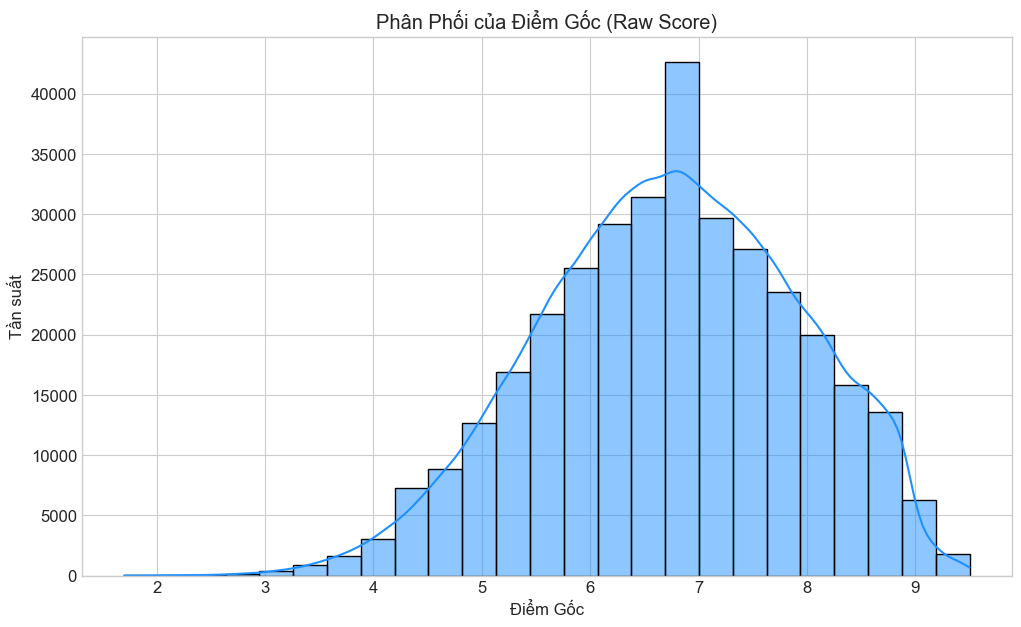

In [228]:
if df is not None:
    plt.figure(figsize=(12, 7))
    sns.histplot(df_processed['raw_score'], kde=True,color='dodgerblue',bins=25)
    plt.title('Phân Phối của Điểm Gốc (Raw Score)')
    plt.xlabel('Điểm Gốc')
    plt.ylabel('Tần suất')
    
    # --- LƯU BIỂU ĐỒ ---
    filename = 'distribution_raw_score.png'
    filepath = os.path.join(PLOTS_DIR, filename)
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"Đã lưu biểu đồ vào: {filepath}")
    # --- HIỂN THỊ BIỂU ĐỒ ---
    plt.show()

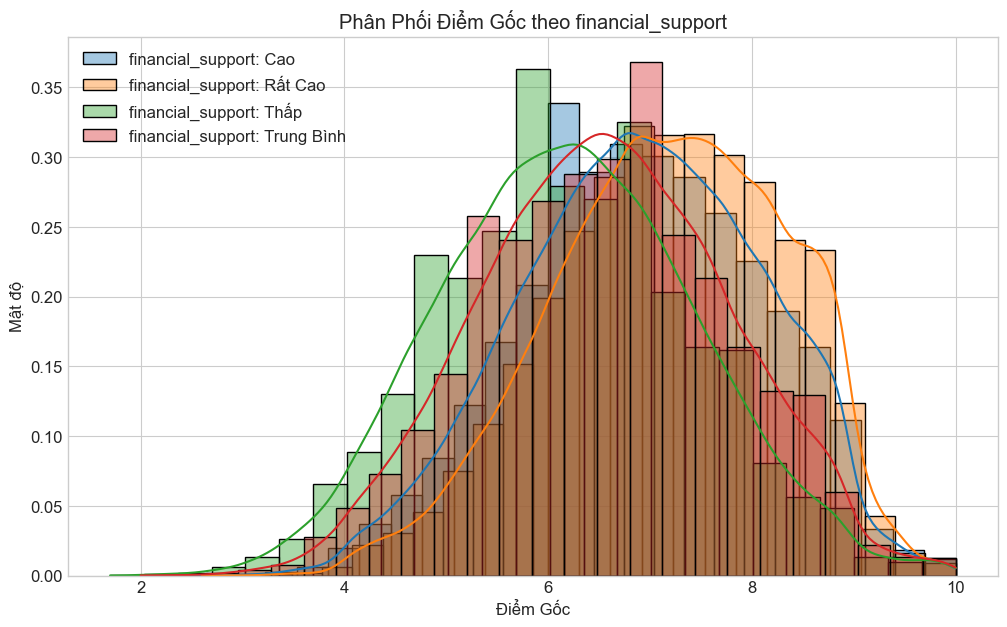

Đã lưu: plots_6_12_2025_1\distribution_by_Hỗ Trợ Tài Chính.png


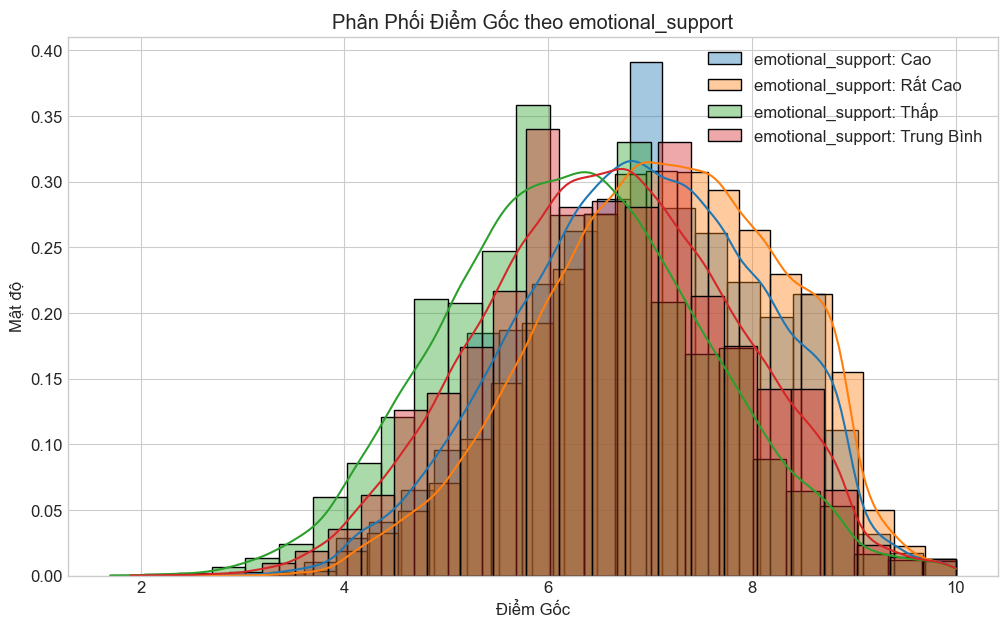

Đã lưu: plots_6_12_2025_1\distribution_by_Hỗ Trợ Tinh Thần.png


In [229]:
group_columns = {
    'Hỗ Trợ Tài Chính': 'financial_support',
    'Hỗ Trợ Tinh Thần': 'emotional_support'
}

# Vẽ biểu đồ cho từng nhóm
for col, label in group_columns.items():
    plt.figure(figsize=(12, 7))
    for val in sorted(df[col].dropna().unique()):
        subset = df[df[col] == val]
        sns.histplot(subset['Điểm gốc'], kde=True, bins=25, label=f"{label}: {val}", stat='density', alpha=0.4)
    
    plt.title(f"Phân Phối Điểm Gốc theo {label}")
    plt.xlabel("Điểm Gốc")
    plt.ylabel("Mật độ")
    plt.legend()
    
    filename = f'distribution_by_{col}.png'
    filepath = os.path.join(PLOTS_DIR, filename)
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Đã lưu: {filepath}")

Đã lưu biểu đồ vào: plots_6_12_2025_1\scatter_gpa_vs_study_hours.png


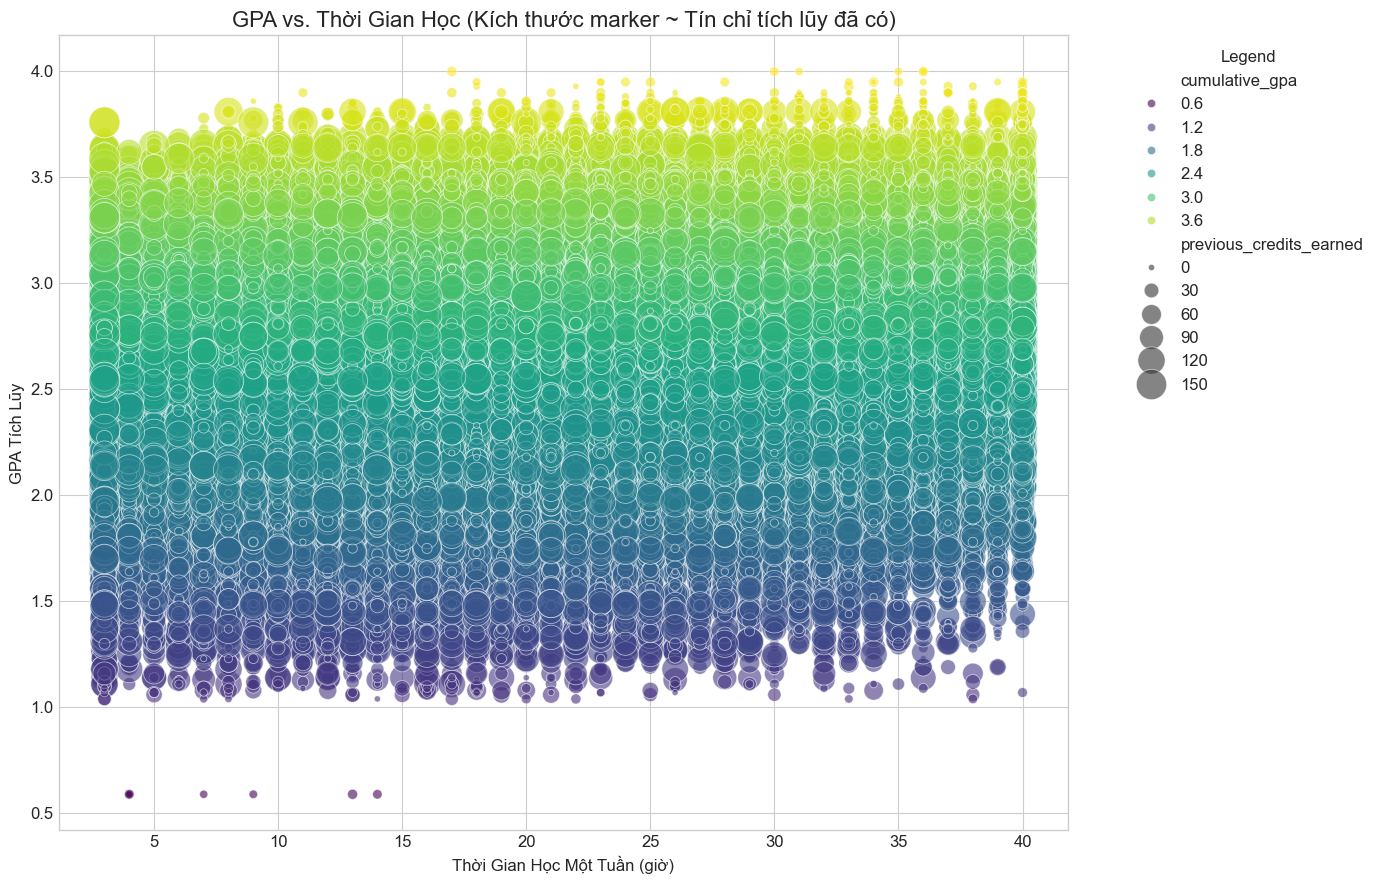

In [230]:
if df is not None:
    plt.figure(figsize=(14, 9))
    
    scatter = sns.scatterplot(
        data=df_processed,
        x='weekly_study_hours',
        y='cumulative_gpa',
        size='previous_credits_earned',
        sizes=(20, 500),
        alpha=0.6,
        hue='cumulative_gpa', 
        palette='viridis'
    )
    
    scatter.set_title('GPA vs. Thời Gian Học (Kích thước marker ~ Tín chỉ tích lũy đã có)', fontsize=16)
    scatter.set_xlabel('Thời Gian Học Một Tuần (giờ)')
    scatter.set_ylabel('GPA Tích Lũy')
    
    plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    # --- LƯU BIỂU ĐỒ ---
    filename = 'scatter_gpa_vs_study_hours.png'
    filepath = os.path.join(PLOTS_DIR, filename)
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"Đã lưu biểu đồ vào: {filepath}")
    # --- HIỂN THỊ BIỂU ĐỒ ---
    plt.show()

Đã lưu biểu đồ vào: plots_6_12_2025_1\point_gpa_by_family_support1.png


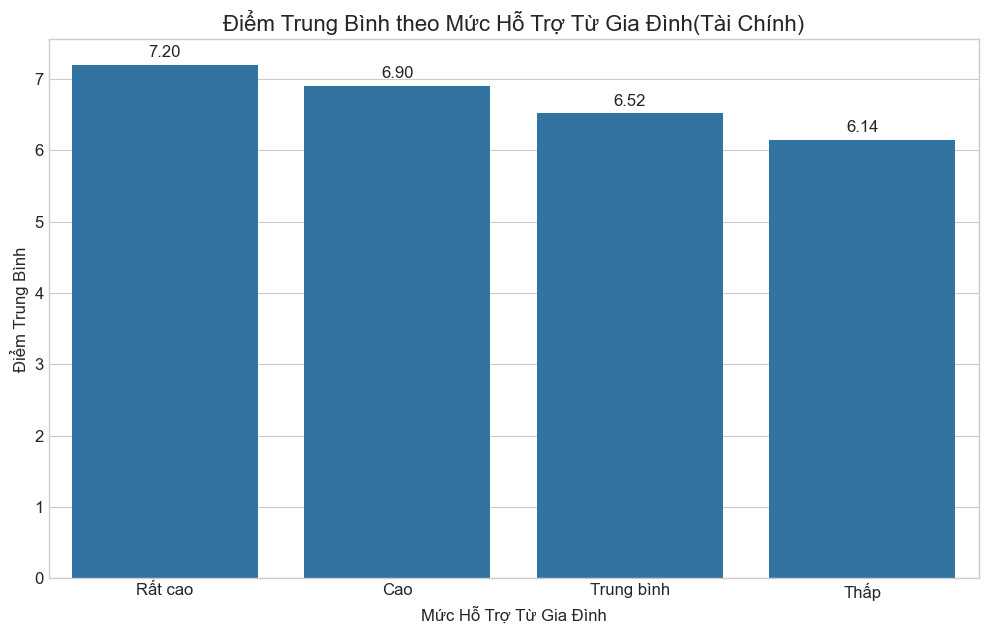

In [231]:
if df is not None:
    # Tính GPA trung bình theo mức độ hỗ trợ đã được mã hóa
    gpa_by_support = df_processed.groupby('financial_support')['raw_score'].mean()
    # Tạo lại các nhãn chữ để hiển thị trên biểu đồ
    support_labels = {0: 'Thấp', 1: 'Trung bình', 2: 'Cao', 3: 'Rất cao'}
    gpa_by_support.index = gpa_by_support.index.map(support_labels)
    
    # Sắp xếp lại sau khi đã có nhãn
    gpa_by_support = gpa_by_support.sort_values(ascending=False)
    
    plt.figure(figsize=(12, 7))
    ax = sns.barplot(x=gpa_by_support.index, y=gpa_by_support.values)
    
    # Hiển thị giá trị trên mỗi cột
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points')
    
    ax.set_title('Điểm Trung Bình theo Mức Hỗ Trợ Từ Gia Đình(Tài Chính)', fontsize=16)
    ax.set_xlabel('Mức Hỗ Trợ Từ Gia Đình')
    ax.set_ylabel('Điểm Trung Bình')
    plt.xticks(rotation=0)

    # --- LƯU BIỂU ĐỒ ---
    filename = 'point_gpa_by_family_support1.png'
    filepath = os.path.join(PLOTS_DIR, filename)
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"Đã lưu biểu đồ vào: {filepath}")
    # --- HIỂN THỊ BIỂU ĐỒ ---
    plt.show()

Đã lưu biểu đồ vào: plots_6_12_2025_1\point_gpa_by_family_support2.png


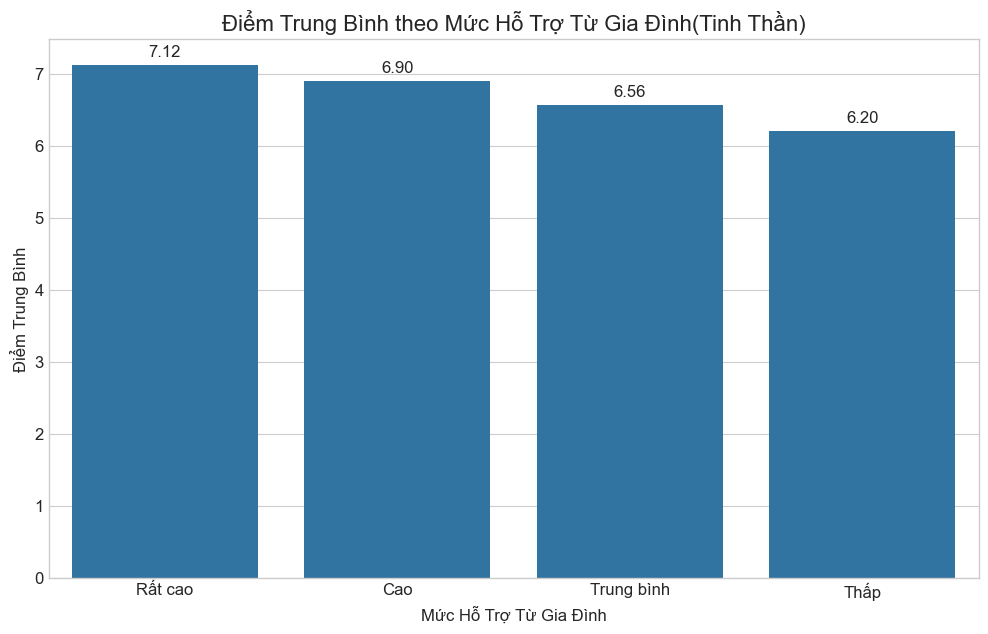

In [232]:
if df is not None:
    # Tính GPA trung bình theo mức độ hỗ trợ đã được mã hóa
    gpa_by_support = df_processed.groupby('emotional_support')['raw_score'].mean()
    # Tạo lại các nhãn chữ để hiển thị trên biểu đồ
    support_labels = {0: 'Thấp', 1: 'Trung bình', 2: 'Cao', 3: 'Rất cao'}
    gpa_by_support.index = gpa_by_support.index.map(support_labels)
    
    # Sắp xếp lại sau khi đã có nhãn
    gpa_by_support = gpa_by_support.sort_values(ascending=False)
    
    plt.figure(figsize=(12, 7))
    ax = sns.barplot(x=gpa_by_support.index, y=gpa_by_support.values)
    
    # Hiển thị giá trị trên mỗi cột
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points')
    
    ax.set_title('Điểm Trung Bình theo Mức Hỗ Trợ Từ Gia Đình(Tinh Thần)', fontsize=16)
    ax.set_xlabel('Mức Hỗ Trợ Từ Gia Đình')
    ax.set_ylabel('Điểm Trung Bình')
    plt.xticks(rotation=0)

    # --- LƯU BIỂU ĐỒ ---
    filename = 'point_gpa_by_family_support2.png'
    filepath = os.path.join(PLOTS_DIR, filename)
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"Đã lưu biểu đồ vào: {filepath}")
    # --- HIỂN THỊ BIỂU ĐỒ ---
    plt.show()

Đã lưu biểu đồ vào: plots_6_12_2025_1\heatmap_correlation_matrix.png


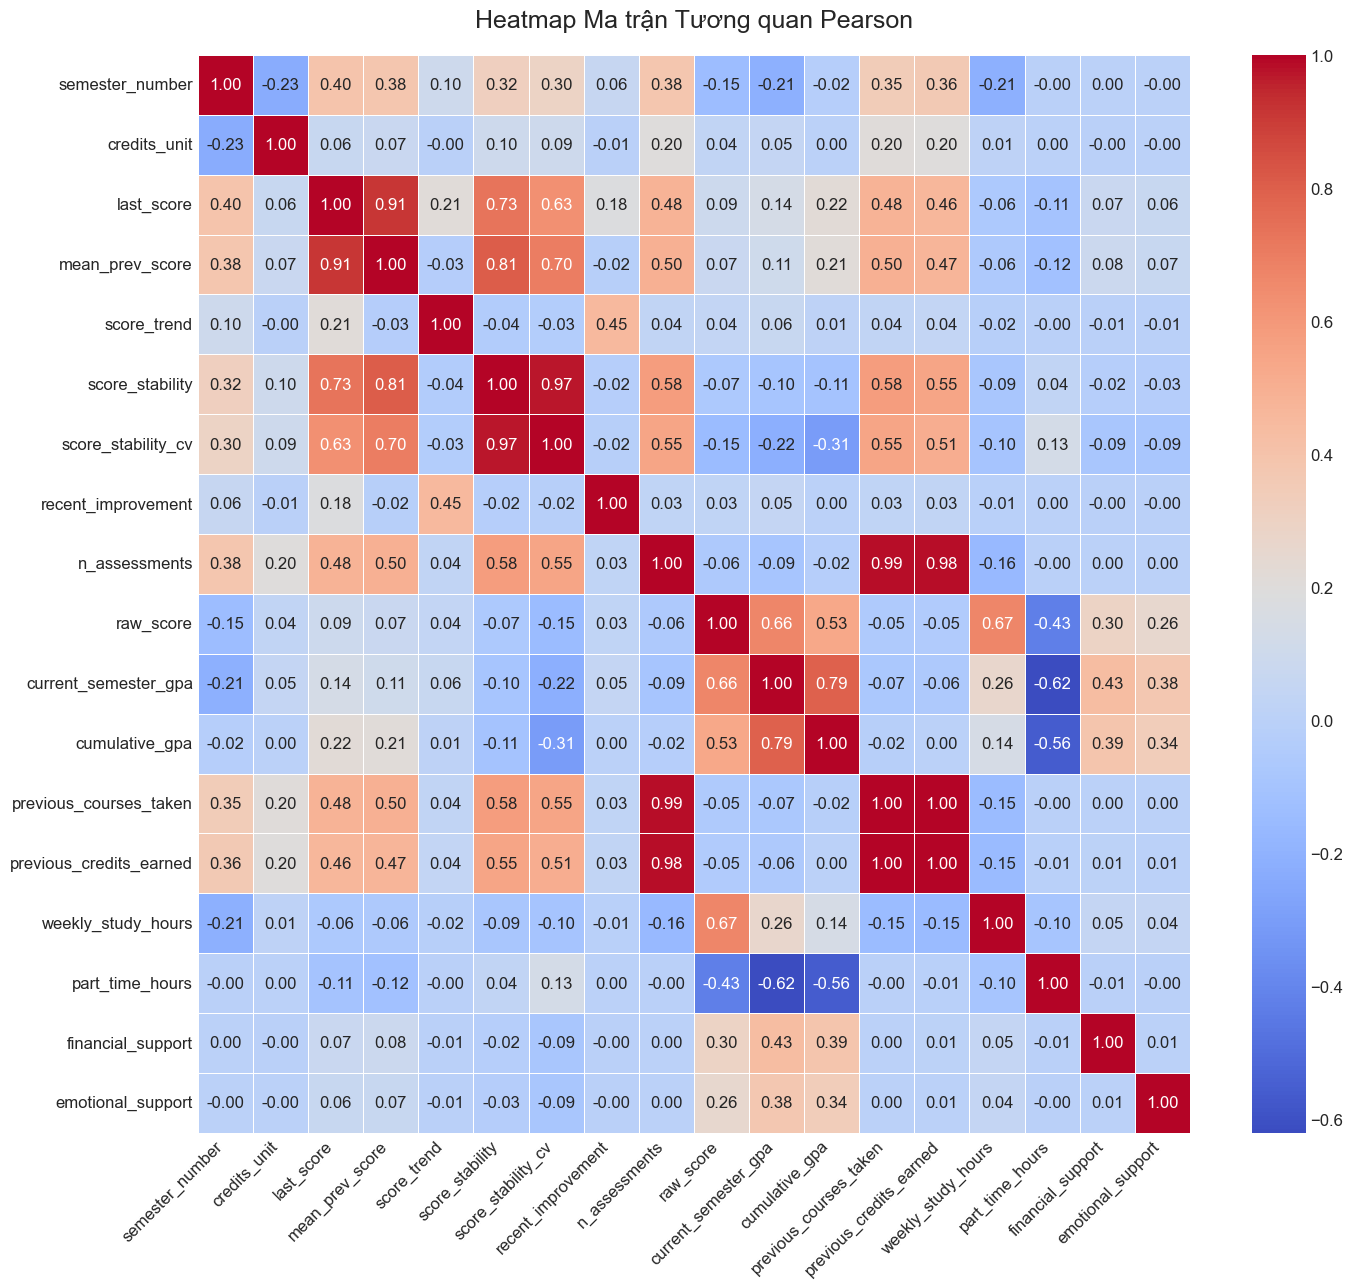

In [233]:
if df is not None:
    plt.figure(figsize=(16, 14))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
    plt.title('Heatmap Ma trận Tương quan Pearson', fontsize=18, pad=20)
    plt.xticks(rotation=45, ha='right')
    
    filepath = os.path.join(PLOTS_DIR, 'heatmap_correlation_matrix.png')
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"Đã lưu biểu đồ vào: {filepath}")
    plt.show()

In [234]:
print("\n5 dòng đầu tiên trước khi feature engineering:")
display(df_processed.head())


5 dòng đầu tiên trước khi feature engineering:


,student_id,semester_number,year,course_code,study_format,credits_unit,last_score,mean_prev_score,score_trend,score_stability,...,n_assessments,raw_score,current_semester_gpa,cumulative_gpa,previous_courses_taken,previous_credits_earned,weekly_study_hours,part_time_hours,financial_support,emotional_support
0,SV0001,1,2022-2023,CMU-SE 100,LEC,3,0.0,0.0,0.0,0.0,...,0,8.2,3.42,3.42,0,0,32,1,2,2
1,SV0001,1,2022-2023,CS 201,LEC,2,0.0,0.0,0.0,0.0,...,0,7.2,3.42,3.42,1,3,18,1,2,2
2,SV0001,1,2022-2023,CS 201,LAB,1,0.0,0.0,0.0,0.0,...,0,6.5,3.42,3.42,2,5,16,1,2,2
3,SV0001,1,2022-2023,CS 211,LEC,3,0.0,0.0,0.0,0.0,...,0,8.4,3.42,3.42,3,6,36,1,2,2
4,SV0001,1,2022-2023,CS 211,LAB,1,0.0,0.0,0.0,0.0,...,0,7.1,3.42,3.42,4,9,10,1,2,2


In [236]:
import pandas as pd
import numpy as np


def generate_features(df: pd.DataFrame) -> pd.DataFrame:
    df_eng = df.copy()
    print("Feature engineering")

    # =========================
    # 0) SAFETY CHECK
    # =========================
    required_base = [
        'student_id', 'course_code', 'raw_score',
        'weekly_study_hours', 'part_time_hours',
        'financial_support', 'emotional_support'
    ]
    missing = [c for c in required_base if c not in df_eng.columns]
    if missing:
        raise ValueError(f"Thiếu cột bắt buộc để FE: {missing}")

    # Ép numeric các cột quan trọng (an toàn)
    for c in [
        'raw_score', 'weekly_study_hours', 'part_time_hours',
        'financial_support', 'emotional_support'
    ]:
        df_eng[c] = pd.to_numeric(df_eng[c], errors='coerce')

    # =========================
    # 1) INTERACTION FEATURES
    # =========================
    df_eng['study_hours_x_part_time_hours'] = (
        df_eng['weekly_study_hours'] * df_eng['part_time_hours']
    )

    df_eng['financial_support_x_part_time_hours'] = (
        df_eng['financial_support'] * df_eng['part_time_hours']
    )

    print("Interaction features")

    # =========================
    # 2) DOMAIN KNOWLEDGE
    # =========================
    subject_type_map = {
        'CMU-SE 100': 'major',
        'CS 201': 'general',
        'CS 211': 'major',
        'DTE-IS 102': 'major',
        'IS-ENG 136': 'major',
        'CHE 101': 'general',
        'CMU-CS 252': 'major',
        'CMU-CS 311': 'major',
        'DTE-IS 152': 'major',
        'IS-ENG 137': 'major',
        'IS-ENG 186': 'major',
        'MTH 103': 'general',
        'COM 141': 'general',
        'PHY 101': 'major',
        'CMU-CS 303': 'major',
        'CMU-SE 214': 'major',
        'HIS 222': 'general',
        'IS-ENG 187': 'major',
        'IS-ENG 236': 'major',
        'MTH 104': 'general',
        'PHI 100': 'general',
        'CMU-CS 246': 'major',
        'CMU-CS 297': 'major',
        'CMU-CS 316': 'major',
        'CMU-ENG 130': 'major',
        'COM 142': 'general',
        'EVR 205': 'general',
        'MTH 254': 'major',
        'STA 151': 'general',
        'CMU-IS 432': 'major',
        'CMU-SE 252': 'major',
        'CMU-SE 303': 'major',
        'IS 301': 'major',
        'MTH 291': 'major',
        'PHI 150': 'general',
        'CMU-CS 445': 'major',
        'CMU-CS 447': 'major',
        'CMU-CS 462': 'major',
        'CMU-ENG 230': 'major',
        'CS 464': 'major',
        'MTH 203': 'general',
        'MTH 204': 'general',
        'MTH 341': 'major',
        'CMU-IS 401': 'major',
        'CS 466': 'major',
        'LAW 201': 'general',
        'POS 151': 'general',
        'POS 361': 'general',
        'HIS 221': 'general',
        'CMU-SE 450': 'major',
        'CMU-SE 403': 'major',
        'CMU-SE 451': 'major',
        'CMU-SE 433': 'major',
        'POS 351': 'general',
        'HIS 362': 'general',
        'IS 385': 'general',
    }

    difficulty_map = {
        'CMU-SE 100': 1,
        'CS 201': 1,
        'CS 211': 2,
        'DTE-IS 102': 1,
        'IS-ENG 136': 2,
        'CHE 101': 2,
        'CMU-CS 252': 1,
        'CMU-CS 311': 3,
        'DTE-IS 152': 1,
        'IS-ENG 137': 2,
        'IS-ENG 186': 2,
        'MTH 103': 3,
        'COM 141': 1,
        'PHY 101': 2,
        'CMU-CS 303': 3,
        'CMU-SE 214': 2,
        'HIS 222': 1,
        'IS-ENG 187': 2,
        'IS-ENG 236': 2,
        'MTH 104': 2,
        'PHI 100': 1,
        'CMU-CS 246': 2,
        'CMU-CS 297': 1,
        'CMU-CS 316': 3,
        'CMU-ENG 130': 2,
        'COM 142': 1,
        'EVR 205': 1,
        'MTH 254': 2,
        'STA 151': 1,
        'CMU-IS 432': 3,
        'CMU-SE 252': 3,
        'CMU-SE 303': 3,
        'IS 301': 3,
        'MTH 291': 2,
        'PHI 150': 1,
        'CMU-CS 445': 3,
        'CMU-CS 447': 2,
        'CMU-CS 462': 3,
        'CMU-ENG 230': 2,
        'CS 464': 3,
        'MTH 203': 2,
        'MTH 204': 2,
        'MTH 341': 2,
        'CMU-IS 401': 3,
        'CS 466': 3,
        'LAW 201': 1,
        'POS 151': 1,
        'POS 361': 1,
        'HIS 221': 1,
        'CMU-SE 450': 3,
        'CMU-SE 403': 3,
        'CMU-SE 451': 3,
        'CMU-SE 433': 3,
        'POS 351': 1,
        'HIS 362': 1,
        'IS 385': 3,
    }

    # chuẩn hóa course_code để map
    df_eng['course_code_clean'] = df_eng['course_code'].astype(str).str.strip()

    df_eng['subject_type'] = df_eng['course_code_clean'].map(subject_type_map)
    df_eng['expected_difficulty'] = df_eng['course_code_clean'].map(difficulty_map)

    # fill difficulty default = 2
    df_eng['expected_difficulty'] = df_eng['expected_difficulty'].fillna(2)

    print("Domain-knowledge features.")

    # fail_rate theo student_id & subject_type
    fail_rate = df_eng.groupby(['student_id', 'subject_type'], observed=False)['raw_score'].transform(
        lambda x: (x < 3.9).mean()
    )

    df_eng['fail_rate_general'] = np.where(df_eng['subject_type'] == 'general', fail_rate, 0)
    df_eng['fail_rate_major'] = np.where(df_eng['subject_type'] == 'major', fail_rate, 0)

    df_eng['fail_rate_general'] = df_eng['fail_rate_general'].fillna(0)
    df_eng['fail_rate_major'] = df_eng['fail_rate_major'].fillna(0)

    print("Thêm các đặc trưng theo subject_type.")

    # ==================================
    # 3) OPTIONAL BONUS FEATURES
    # ==================================
    # study_load: tải học theo tín chỉ (nếu có)
    if 'credits_unit' in df_eng.columns:
        df_eng['credits_unit'] = pd.to_numeric(df_eng['credits_unit'], errors='coerce').fillna(0)
        df_eng['study_load'] = df_eng['weekly_study_hours'] / (df_eng['credits_unit'] + 1e-6)
    else:
        df_eng['study_load'] = 0

    print("Optional bonus features.")

    # =========================
    # 4) CLEANUP an toàn
    # =========================
    cols_new = [
        # interaction
        'study_hours_x_part_time_hours',
        'financial_support_x_part_time_hours',

        # domain
        'expected_difficulty',
        'fail_rate_general',
        'fail_rate_major',

        # optional
        'study_load',
    ]

    cols_new = [c for c in cols_new if c in df_eng.columns]

    # Dropna nhẹ theo các feature mới tạo
    df_eng.dropna(subset=cols_new, inplace=True)

    # dọn cột phụ
    df_eng.drop(columns=['course_code_clean'], errors='ignore', inplace=True)

    print(f"Feature engineering hoàn tất: {df_eng.shape[0]} dòng, {df_eng.shape[1]} cột.")
    return df_eng


In [237]:
# ==========================================
# FEATURE ENGINEERING - PREVIEW & SANITY CHECK
# (dùng với generate_features phiên bản mới)
# - FE KHÔNG TẠO historical/efficiency nữa
# - historical giờ là cột có sẵn từ generate data
# ==========================================

from IPython.display import display
import numpy as np
import pandas as pd

if 'df_processed' in locals():
    print("\nTiến hành sinh đặc trưng từ df_processed...")
    df_featured = generate_features(df_processed)

    print("\nKIỂM TRA KẾT QUẢ ---")

    # =========================
    # 1) Các cột gốc quan trọng
    # =========================
    base_cols = [
        'student_id', 'course_code', 'year', 'semester_number',
        'study_format', 'credits_unit',
        'weekly_study_hours', 'part_time_hours',
        'financial_support', 'emotional_support',
        'raw_score'
    ]

    # =========================
    # 2) Interaction features (tạo bởi FE)
    # =========================
    interaction_cols = [
        'study_hours_x_part_time_hours',
        'financial_support_x_part_time_hours',
    ]

    # =========================
    # 3) Domain-knowledge (tạo bởi FE)
    # =========================
    domain_cols = [
        'subject_type',
        'expected_difficulty',
        'fail_rate_general',
        'fail_rate_major',
    ]

    # =========================
    # 4) Historical academic
    # (KHÔNG tạo bởi FE nữa - kỳ vọng đã có sẵn từ generate data)
    # =========================
    historical_cols = [
        'last_score',
        'mean_prev_score',
        'score_trend',
        'score_stability',
        'score_stability_cv',
        'recent_improvement',
        'n_assessments',
    ]

    # =========================
    # 5) Optional bonus (tạo bởi FE)
    # =========================
    optional_cols = [
        'study_load',
    ]

    # Gộp danh sách preview
    preview_columns = (
        base_cols
        + interaction_cols
        + domain_cols
        + historical_cols
        + optional_cols
    )

    # Chỉ giữ các cột tồn tại
    preview_columns_valid = [c for c in preview_columns if c in df_featured.columns]

    # Báo các cột mong đợi nhưng không có
    missing_cols = [c for c in preview_columns if c not in df_featured.columns]
    if missing_cols:
        print("\n[CẢNH BÁO] Một số cột không tồn tại trong df_featured:")
        print(missing_cols)
        print(
            "\nGợi ý nhanh:\n"
            "- Nếu thiếu historical_cols: kiểm tra bước map/rename từ file generated "
            "('last_score', 'mean_prev_score', ...).\n"
            "- Nếu thiếu year/semester_number/credits_unit: kiểm tra pipeline chuẩn hóa df_processed."
        )

    # Hiển thị bảng kết quả
    display(df_featured[preview_columns_valid].head(10))

    print(f"\nTổng số cột sau FE: {df_featured.shape[1]} cột")
    print(f"Số dòng dữ liệu hợp lệ: {df_featured.shape[0]} dòng")

    # =========================
    # Thống kê nhanh theo nhóm
    # =========================
    def _count_existing(cols):
        return sum([1 for c in cols if c in df_featured.columns])

    print("\nTÓM TẮT NHANH THEO NHÓM:")
    print(f"- Base cols có mặt: {_count_existing(base_cols)}/{len(base_cols)}")
    print(f"- Interaction cols có mặt: {_count_existing(interaction_cols)}/{len(interaction_cols)}")
    print(f"- Domain cols có mặt: {_count_existing(domain_cols)}/{len(domain_cols)}")
    print(f"- Historical cols có mặt: {_count_existing(historical_cols)}/{len(historical_cols)}")
    print(f"- Optional cols có mặt: {_count_existing(optional_cols)}/{len(optional_cols)}")

    # =========================
    # Encode nhẹ subject_type (nếu muốn dùng ngay)
    # =========================
    if 'subject_type' in df_featured.columns:
        subject_type_map_numeric = {'general': 1, 'major': 2}
        df_featured['subject_type_num'] = (
            df_featured['subject_type']
            .map(subject_type_map_numeric)
            .fillna(0)
            .astype(int)
        )

    # =========================
    # Sanity check nhanh một số cột key
    # (đã bỏ study_efficiency vì FE không tạo nữa)
    # =========================
    quick_check_cols = [
        'raw_score',
        'weekly_study_hours',
        'part_time_hours',
        'financial_support',
        'emotional_support',
        'last_score',
        'mean_prev_score',
        'score_stability',
        'score_trend',
        'study_load'
    ]
    quick_check_cols = [c for c in quick_check_cols if c in df_featured.columns]

    print("\nDESCRIBE NHANH (một số cột key):")
    display(df_featured[quick_check_cols].describe().T)

    # =========================
    # (Tuỳ chọn) Lưu dataset mới để train
    # =========================
    OUT_PATH = "clean_student_data_v2.csv"
    df_featured.to_csv(OUT_PATH, index=False)
    print(f"\nĐã lưu dataset sau FE: {OUT_PATH}")

else:
    print("Biến df_processed chưa tồn tại. Vui lòng kiểm tra lại.")



Tiến hành sinh đặc trưng từ df_processed...
Feature engineering
Interaction features
Domain-knowledge features.
Thêm các đặc trưng theo subject_type.
Optional bonus features.
Feature engineering hoàn tất: 340000 dòng, 29 cột.

KIỂM TRA KẾT QUẢ ---


,student_id,course_code,year,semester_number,study_format,credits_unit,weekly_study_hours,part_time_hours,financial_support,emotional_support,...,fail_rate_general,fail_rate_major,last_score,mean_prev_score,score_trend,score_stability,score_stability_cv,recent_improvement,n_assessments,study_load
0,SV0001,CMU-SE 100,2022-2023,1,LEC,3,32,1,2,2,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.00,0,10.666663
1,SV0001,CS 201,2022-2023,1,LEC,2,18,1,2,2,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.00,0,8.999996
2,SV0001,CS 201,2022-2023,1,LAB,1,16,1,2,2,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.00,0,15.999984
3,SV0001,CS 211,2022-2023,1,LEC,3,36,1,2,2,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.00,0,11.999996
4,SV0001,CS 211,2022-2023,1,LAB,1,10,1,2,2,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.00,0,9.999990
5,SV0001,DTE-IS 102,2022-2023,1,LEC,1,16,1,2,2,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.00,0,15.999984
6,SV0001,IS-ENG 136,2022-2023,1,LEC,3,31,1,2,2,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.00,0,10.333330
7,SV0001,CHE 101,2022-2023,2,LEC,2,37,2,2,1,...,0.0,0.0,8.2,7.628571,0.217143,0.656211,0.08602,0.25,7,18.499991
8,SV0001,CHE 101,2022-2023,2,LAB,1,15,2,2,1,...,0.0,0.0,8.2,7.628571,0.217143,0.656211,0.08602,0.25,7,14.999985
9,SV0001,CMU-CS 252,2022-2023,2,LEC,3,17,2,2,1,...,0.0,0.0,8.2,7.628571,0.217143,0.656211,0.08602,0.25,7,5.666665



Tổng số cột sau FE: 29 cột
Số dòng dữ liệu hợp lệ: 340000 dòng

TÓM TẮT NHANH THEO NHÓM:
- Base cols có mặt: 11/11
- Interaction cols có mặt: 2/2
- Domain cols có mặt: 4/4
- Historical cols có mặt: 7/7
- Optional cols có mặt: 1/1

DESCRIBE NHANH (một số cột key):


,count,mean,std,min,25%,50%,75%,max
raw_score,340000.0,6.719466,1.197470,1.70,5.900000,6.700000,7.600000,9.500000
weekly_study_hours,340000.0,21.912159,10.024163,3.00,14.000000,22.000000,30.000000,40.000000
part_time_hours,340000.0,20.170965,11.895908,0.00,10.000000,20.000000,30.000000,40.000000
financial_support,340000.0,1.566706,0.992949,0.00,1.000000,2.000000,2.000000,3.000000
emotional_support,340000.0,1.540544,0.991256,0.00,1.000000,2.000000,2.000000,3.000000
last_score,340000.0,6.019781,2.333782,0.00,5.500000,6.600000,7.500000,9.500000
mean_prev_score,340000.0,6.064723,2.141559,0.00,6.131034,6.700000,7.151724,8.957143
score_stability,340000.0,0.877043,0.340662,0.00,0.823347,0.962421,1.073301,1.815840
score_trend,340000.0,-0.014098,0.166587,-0.25,-0.160000,0.000000,0.117143,0.250000
study_load,340000.0,12.234837,8.755529,0.75,5.999998,9.999995,14.999993,39.999960



Đã lưu dataset sau FE: clean_student_data_v2.csv


In [238]:
# =========================
# CELL TIẾP THEO: Chuẩn bị feature set cuối cùng cho model
# (Aligned với generate_features phiên bản mới:
#  - FE KHÔNG tạo historical/efficiency nữa
#  - Historical features được kỳ vọng đã có sẵn từ generate data
#  - giữ course_code + study_format là categorical
#  - split theo student_id để tránh leakage)
# =========================

import pandas as pd
import numpy as np
from IPython.display import display

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

if 'df_featured' in locals():

    df_model = df_featured.copy()

    # =========================
    # 1) Chuẩn hóa kiểu dữ liệu cơ bản
    # =========================
    # subject_type: nếu còn là text thì map sang numeric (giữ như 1 domain signal)
    if 'subject_type' in df_model.columns:
        if df_model['subject_type'].dtype == 'O' or str(df_model['subject_type'].dtype).startswith('string'):
            subject_type_map_numeric = {'general': 1, 'major': 2}
            df_model['subject_type'] = df_model['subject_type'].map(subject_type_map_numeric)
    # =========================
    # 2) Fallback cho study_load
    # =========================
    # Ưu tiên công thức nhẹ & ổn định:
    # study_load = weekly_study_hours / credits_unit
    if 'study_load' not in df_model.columns:
        if 'credits_unit' in df_model.columns and 'weekly_study_hours' in df_model.columns:
            df_model['credits_unit'] = pd.to_numeric(df_model['credits_unit'], errors='coerce')
            df_model['weekly_study_hours'] = pd.to_numeric(df_model['weekly_study_hours'], errors='coerce')
            df_model['study_load'] = df_model['weekly_study_hours'] / (df_model['credits_unit'] + 1e-6)
        else:
            df_model['study_load'] = np.nan

    # =========================
    # 3) Khai báo feature groups theo yêu cầu A/B/C/D
    # =========================

    # A. Raw features
    raw_features = [
        'semester_number',
        'course_code',
        'study_format',
        'credits_unit',
        'weekly_study_hours',
        'part_time_hours',
        'financial_support',
        'emotional_support'
    ]

    # B. Interaction features (tạo bởi FE)
    interaction_features = [
        'study_hours_x_part_time_hours',
        'financial_support_x_part_time_hours',
    ]

    # C. Historical academic features
    # (đã có từ generate data; nếu thiếu thì sẽ tự loại khỏi feature_cols)
    historical_features = [
        'last_score',
        'mean_prev_score',
        'score_trend',
        'score_stability',
        'score_stability_cv',
        'recent_improvement',
        'n_assessments'
    ]

    # D. Optional bonus features
    optional_features = [
        'study_load'
    ]

    # Domain signals bổ sung (nếu có)
    domain_features = []
    for c in ['subject_type', 'expected_difficulty', 'fail_rate_general', 'fail_rate_major']:
        if c in df_model.columns:
            domain_features.append(c)

    # Gộp feature list
    feature_cols = (
        raw_features
        + interaction_features
        + historical_features
        + optional_features
        + domain_features
    )

    # 5) Lọc các cột thực sự tồn tại
    feature_cols = [c for c in feature_cols if c in df_model.columns]

    # 6) Kiểm tra target
    target_col = 'raw_score'
    if target_col not in df_model.columns:
        raise ValueError("Không tìm thấy cột target 'raw_score' trong df_featured.")

    # 7) Làm sạch NaN cho feature + target
    df_model_clean = df_model.dropna(subset=feature_cols + [target_col]).copy()

    # =========================
    # 8) Tạo X, y (raw)
    # =========================
    X = df_model_clean[feature_cols].copy()
    y = df_model_clean[target_col].copy()

    print("\nTỔNG KẾT DATASET CHO MODEL ---")
    print(f"Số feature dùng train: {len(feature_cols)}")
    print(f"Kích thước X: {X.shape}")
    print(f"Kích thước y: {y.shape}")

    # =========================
    # 9) Preview nhanh các cột key
    # =========================
    quick_check_cols = [
        'student_id', 'course_code', 'study_format', 'subject_type',
        'expected_difficulty',
        'credits_unit', 'weekly_study_hours', 'study_load',
        'financial_support', 'emotional_support',
        'last_score', 'mean_prev_score', 'score_trend'
    ]
    quick_check_cols = [c for c in quick_check_cols if c in df_model_clean.columns]

    print("\nPREVIEW NHANH ---")
    display(df_model_clean[quick_check_cols].head(10))

    # =========================
    # 10) Split theo student_id để tránh leakage
    # =========================
    if 'student_id' not in df_model_clean.columns:
        raise ValueError("Thiếu 'student_id' để GroupShuffleSplit.")

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    groups = df_model_clean['student_id']

    train_idx, test_idx = next(gss.split(X, y, groups=groups))

    X_train_raw = X.iloc[train_idx].copy()
    X_test_raw  = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test  = y.iloc[test_idx].copy()

    print("\nSPLIT THEO STUDENT_ID ---")
    print(f"Train size: {X_train_raw.shape} | Test size: {X_test_raw.shape}")

    # =========================
    # 11) Xây preprocessing pipeline
    # =========================
    categorical_features = [c for c in ['course_code', 'study_format'] if c in X_train_raw.columns]
    numerical_features = [c for c in X_train_raw.columns if c not in categorical_features]

    print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
    print(f"Numerical features ({len(numerical_features)}): {numerical_features[:12]} ...")

    # OneHotEncoder tương thích nhiều version sklearn
    try:
        categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse=False)

    numerical_transformer = StandardScaler()

    transformers = []
    if categorical_features:
        transformers.append(('cat', categorical_transformer, categorical_features))
    if numerical_features:
        transformers.append(('num', numerical_transformer, numerical_features))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='drop'
    )

    preprocessing_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

    X_train_transformed = preprocessing_pipeline.fit_transform(X_train_raw)
    X_test_transformed  = preprocessing_pipeline.transform(X_test_raw)

    feature_names = preprocessing_pipeline.named_steps['preprocessor'].get_feature_names_out()

    print("\nPREPROCESSING OUTPUT ---")
    print(f"X_train_transformed: {X_train_transformed.shape}")
    print(f"X_test_transformed : {X_test_transformed.shape}")
    print(f"Total feature names: {len(feature_names)}")

    print("\nSample of feature names:")
    display(feature_names[:30])

else:
    print("Chưa có df_featured. Hãy chạy cell generate_features + preview ở trên trước.")



TỔNG KẾT DATASET CHO MODEL ---
Số feature dùng train: 22
Kích thước X: (340000, 22)
Kích thước y: (340000,)

PREVIEW NHANH ---


,student_id,course_code,study_format,subject_type,expected_difficulty,credits_unit,weekly_study_hours,study_load,financial_support,emotional_support,last_score,mean_prev_score,score_trend
0,SV0001,CMU-SE 100,LEC,2,1,3,32,10.666663,2,2,0.0,0.000000,0.000000
1,SV0001,CS 201,LEC,1,1,2,18,8.999996,2,2,0.0,0.000000,0.000000
2,SV0001,CS 201,LAB,1,1,1,16,15.999984,2,2,0.0,0.000000,0.000000
3,SV0001,CS 211,LEC,2,2,3,36,11.999996,2,2,0.0,0.000000,0.000000
4,SV0001,CS 211,LAB,2,2,1,10,9.999990,2,2,0.0,0.000000,0.000000
5,SV0001,DTE-IS 102,LEC,2,1,1,16,15.999984,2,2,0.0,0.000000,0.000000
6,SV0001,IS-ENG 136,LEC,2,2,3,31,10.333330,2,2,0.0,0.000000,0.000000
7,SV0001,CHE 101,LEC,1,2,2,37,18.499991,2,1,8.2,7.628571,0.217143
8,SV0001,CHE 101,LAB,1,2,1,15,14.999985,2,1,8.2,7.628571,0.217143
9,SV0001,CMU-CS 252,LEC,2,1,3,17,5.666665,2,1,8.2,7.628571,0.217143



SPLIT THEO STUDENT_ID ---
Train size: (272000, 22) | Test size: (68000, 22)
Categorical features (2): ['course_code', 'study_format']
Numerical features (20): ['semester_number', 'credits_unit', 'weekly_study_hours', 'part_time_hours', 'financial_support', 'emotional_support', 'study_hours_x_part_time_hours', 'financial_support_x_part_time_hours', 'last_score', 'mean_prev_score', 'score_trend', 'score_stability'] ...

PREPROCESSING OUTPUT ---
X_train_transformed: (272000, 83)
X_test_transformed : (68000, 83)
Total feature names: 83

Sample of feature names:


array(['cat__course_code_CHE 101', 'cat__course_code_CMU-CS 246',
       'cat__course_code_CMU-CS 252', 'cat__course_code_CMU-CS 297',
       'cat__course_code_CMU-CS 303', 'cat__course_code_CMU-CS 311',
       'cat__course_code_CMU-CS 316', 'cat__course_code_CMU-CS 445',
       'cat__course_code_CMU-CS 447', 'cat__course_code_CMU-CS 462',
       'cat__course_code_CMU-ENG 130', 'cat__course_code_CMU-ENG 230',
       'cat__course_code_CMU-IS 401', 'cat__course_code_CMU-IS 432',
       'cat__course_code_CMU-SE 100', 'cat__course_code_CMU-SE 214',
       'cat__course_code_CMU-SE 252', 'cat__course_code_CMU-SE 303',
       'cat__course_code_CMU-SE 403', 'cat__course_code_CMU-SE 433',
       'cat__course_code_CMU-SE 450', 'cat__course_code_CMU-SE 451',
       'cat__course_code_COM 141', 'cat__course_code_COM 142',
       'cat__course_code_CS 201', 'cat__course_code_CS 211',
       'cat__course_code_CS 464', 'cat__course_code_CS 466',
       'cat__course_code_DTE-IS 102', 'cat__course_code_D

In [239]:
if 'df_featured' in locals():
    output_filename = 'clean_student_data_v2.csv'
    df_featured.to_csv(output_filename, index=False, encoding='utf-8-sig')
    print(f"\nĐã lưu DataFrame cuối cùng thành công vào file '{output_filename}'.")
    print(f"Tổng số bản ghi trong file cuối cùng: {len(df_featured)}")


Đã lưu DataFrame cuối cùng thành công vào file 'clean_student_data_v2.csv'.
Tổng số bản ghi trong file cuối cùng: 340000


In [243]:
# Tạo thư mục lưu trữ biểu đồ nếu chưa tồn tại
PLOTS_DIR = 'plots_cleaned2_8_2025/'
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f"Thư mục '{PLOTS_DIR}' đã sẵn sàng.")

# Tải dữ liệu đã được xử lý và feature engineering
try:
    df_featured = pd.read_csv('clean_student_data_v2.csv')
    print("Tải dữ liệu từ 'clean_student_data_v2.csv' thành công.")
except FileNotFoundError:
    print("Lỗi: Không tìm thấy file 'clean_student_data_v2.csv'.")
    df_featured = None

Thư mục 'plots_cleaned2_8_2025/' đã sẵn sàng.
Tải dữ liệu từ 'clean_student_data_v2.csv' thành công.


In [244]:
if df_featured is not None:
    print("5 dòng dữ liệu đầu tiên:")
    display(df_featured.head())
    
    print("\nThông tin các cột và kiểu dữ liệu:")
    df_featured.info()

5 dòng dữ liệu đầu tiên:


,student_id,semester_number,year,course_code,study_format,credits_unit,last_score,mean_prev_score,score_trend,score_stability,...,financial_support,emotional_support,study_hours_x_part_time_hours,financial_support_x_part_time_hours,subject_type,expected_difficulty,fail_rate_general,fail_rate_major,study_load,subject_type_num
0,SV0001,1,2022-2023,CMU-SE 100,LEC,3,0.0,0.0,0.0,0.0,...,2,2,32,2,major,1,0.0,0.0,10.666663,2
1,SV0001,1,2022-2023,CS 201,LEC,2,0.0,0.0,0.0,0.0,...,2,2,18,2,general,1,0.0,0.0,8.999996,1
2,SV0001,1,2022-2023,CS 201,LAB,1,0.0,0.0,0.0,0.0,...,2,2,16,2,general,1,0.0,0.0,15.999984,1
3,SV0001,1,2022-2023,CS 211,LEC,3,0.0,0.0,0.0,0.0,...,2,2,36,2,major,2,0.0,0.0,11.999996,2
4,SV0001,1,2022-2023,CS 211,LAB,1,0.0,0.0,0.0,0.0,...,2,2,10,2,major,2,0.0,0.0,9.999990,2



Thông tin các cột và kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340000 entries, 0 to 339999
Data columns (total 30 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   student_id                           340000 non-null  object 
 1   semester_number                      340000 non-null  int64  
 2   year                                 340000 non-null  object 
 3   course_code                          340000 non-null  object 
 4   study_format                         340000 non-null  object 
 5   credits_unit                         340000 non-null  int64  
 6   last_score                           340000 non-null  float64
 7   mean_prev_score                      340000 non-null  float64
 8   score_trend                          340000 non-null  float64
 9   score_stability                      340000 non-null  float64
 10  score_stability_cv                   340000 

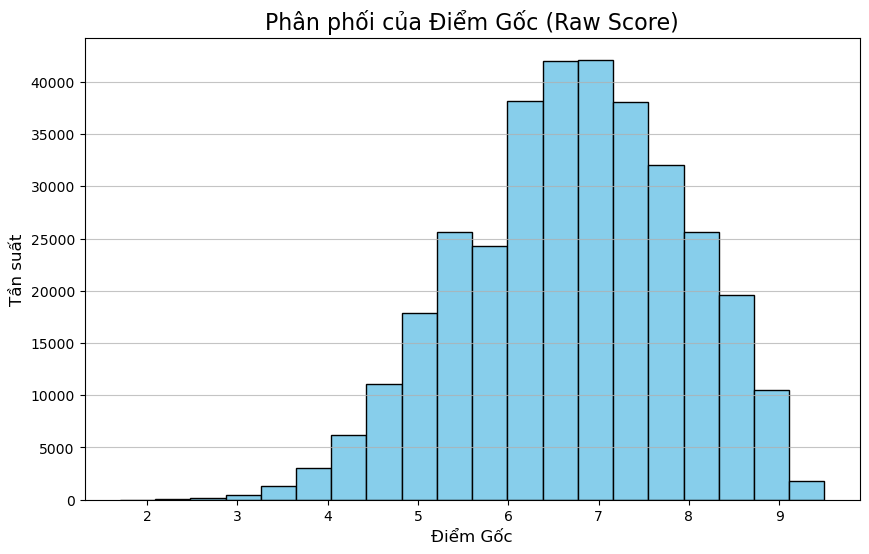

Đã lưu biểu đồ vào: plots_cleaned2_8_2025/raw_score_distribution.png


In [246]:
plt.style.use('default')
plt.figure(figsize=(10, 6))
df_featured['raw_score'].plot(kind='hist', bins=20, color='skyblue', edgecolor='black')
plt.title('Phân phối của Điểm Gốc (Raw Score)', fontsize=16)
plt.xlabel('Điểm Gốc', fontsize=12)
plt.ylabel('Tần suất', fontsize=12)
plt.grid(axis='y', alpha=0.75)

filepath = os.path.join(PLOTS_DIR, 'raw_score_distribution.png')
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.show()
print(f"Đã lưu biểu đồ vào: {filepath}")

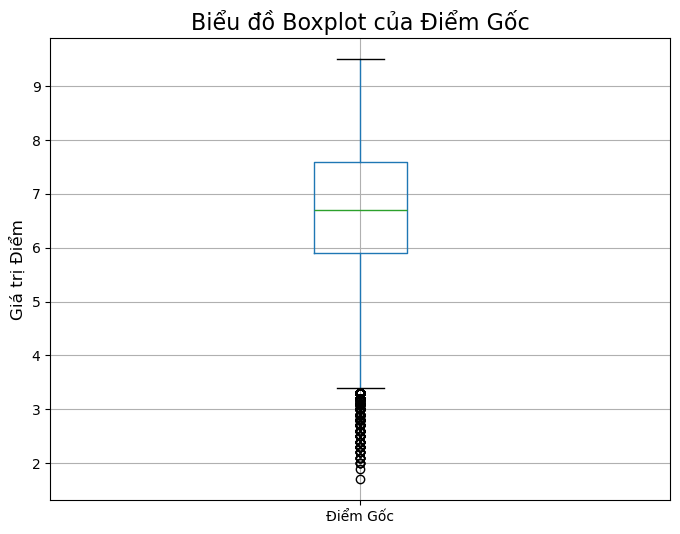

Đã lưu biểu đồ vào: plots_cleaned2_8_2025/raw_score_boxplot.png


In [247]:
plt.figure(figsize=(8, 6))
df_featured.boxplot(column=['raw_score'], grid=True)
plt.title('Biểu đồ Boxplot của Điểm Gốc', fontsize=16)
plt.ylabel('Giá trị Điểm', fontsize=12)
plt.xticks([1], ['Điểm Gốc'])

filepath = os.path.join(PLOTS_DIR, 'raw_score_boxplot.png')
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.show()
print(f"Đã lưu biểu đồ vào: {filepath}")

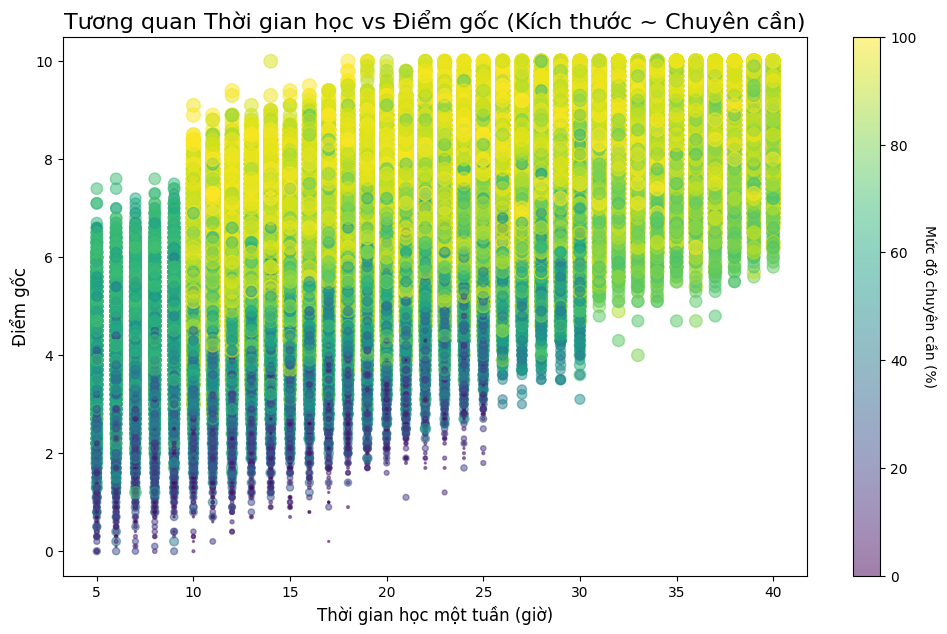

Đã lưu biểu đồ vào: plots_cleaned2_8_2025/study_vs_score.png


In [28]:
plt.figure(figsize=(12, 7))
# Chuyển đổi cột chuyên cần sang dạng số để làm kích thước
size = pd.to_numeric(df_featured['attendance_percentage'].astype(str).str.replace('%', ''), errors='coerce')
plt.scatter(df_featured['weekly_study_hours'], df_featured['raw_score'], alpha=0.5, c=size, cmap='viridis', s=size)
plt.title('Tương quan Thời gian học vs Điểm gốc (Kích thước ~ Chuyên cần)', fontsize=16)
plt.xlabel('Thời gian học một tuần (giờ)', fontsize=12)
plt.ylabel('Điểm gốc', fontsize=12)
cbar = plt.colorbar()
cbar.set_label('Mức độ chuyên cần (%)', rotation=270, labelpad=15)

filepath = os.path.join(PLOTS_DIR, 'study_vs_score.png')
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.show()
print(f"Đã lưu biểu đồ vào: {filepath}")

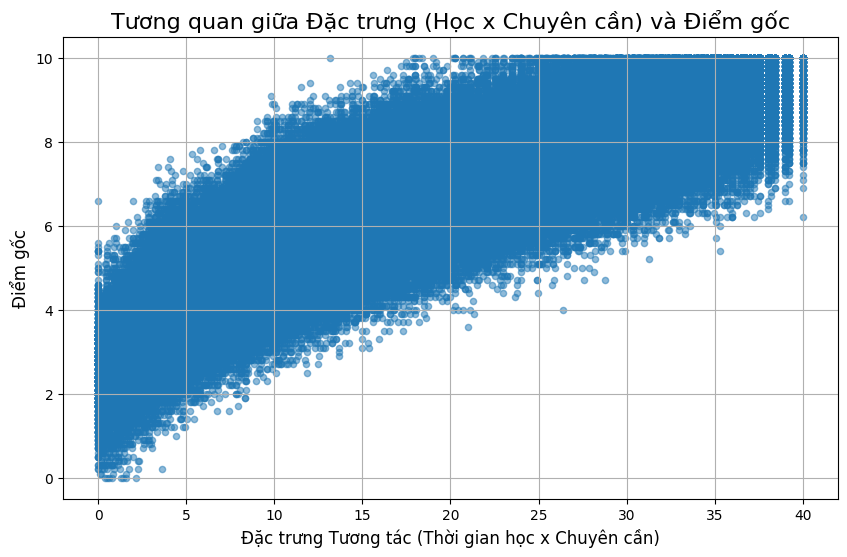

Đã lưu biểu đồ vào: plots_cleaned2_8_2025/study_attendance_interaction.png


In [31]:
df_featured.plot(kind='scatter', x='study_hours_x_attendance', y='raw_score', alpha=0.5, figsize=(10, 6))
plt.title('Tương quan giữa Đặc trưng (Học x Chuyên cần) và Điểm gốc', fontsize=16)
plt.xlabel('Đặc trưng Tương tác (Thời gian học x Chuyên cần)', fontsize=12)
plt.ylabel('Điểm gốc', fontsize=12)
plt.grid(True)

filepath = os.path.join(PLOTS_DIR, 'study_attendance_interaction.png')
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.show()
print(f"Đã lưu biểu đồ vào: {filepath}")

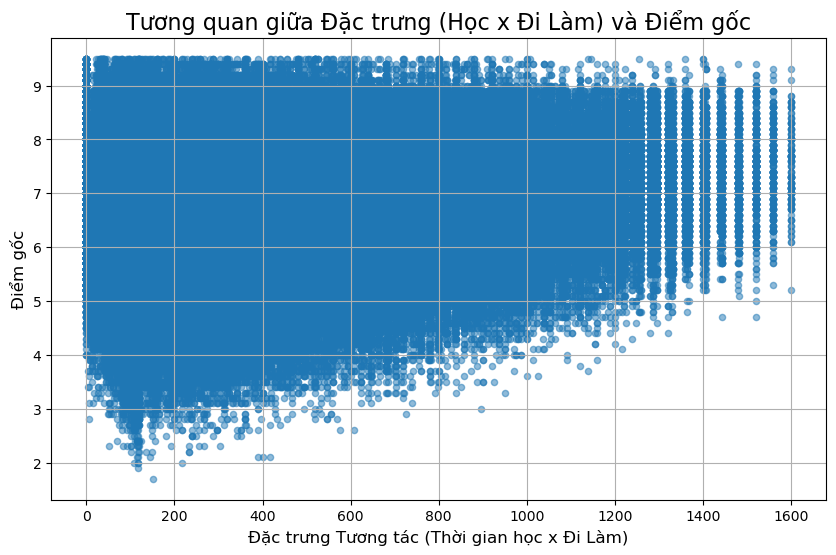

Đã lưu biểu đồ vào: plots_cleaned2_8_2025/study_part_time_interaction.png


In [249]:
df_featured.plot(kind='scatter', x='study_hours_x_part_time_hours', y='raw_score', alpha=0.5, figsize=(10, 6))
plt.title('Tương quan giữa Đặc trưng (Học x Đi Làm) và Điểm gốc', fontsize=16)
plt.xlabel('Đặc trưng Tương tác (Thời gian học x Đi Làm)', fontsize=12)
plt.ylabel('Điểm gốc', fontsize=12)
plt.grid(True)

filepath = os.path.join(PLOTS_DIR, 'study_part_time_interaction.png')
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.show()
print(f"Đã lưu biểu đồ vào: {filepath}")

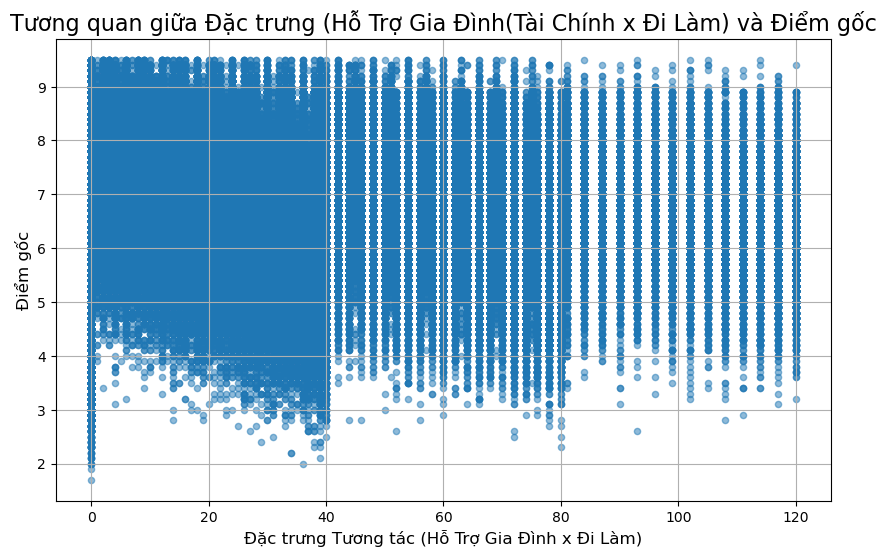

Đã lưu biểu đồ vào: plots_cleaned2_8_2025/family_support_part_time_interaction.png


In [250]:
df_featured.plot(kind='scatter', x='financial_support_x_part_time_hours', y='raw_score', alpha=0.5, figsize=(10, 6))
plt.title('Tương quan giữa Đặc trưng (Hỗ Trợ Gia Đình(Tài Chính x Đi Làm) và Điểm gốc', fontsize=16)
plt.xlabel('Đặc trưng Tương tác (Hỗ Trợ Gia Đình x Đi Làm)', fontsize=12)
plt.ylabel('Điểm gốc', fontsize=12)
plt.grid(True)

filepath = os.path.join(PLOTS_DIR, 'family_support_part_time_interaction.png')
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.show()
print(f"Đã lưu biểu đồ vào: {filepath}")

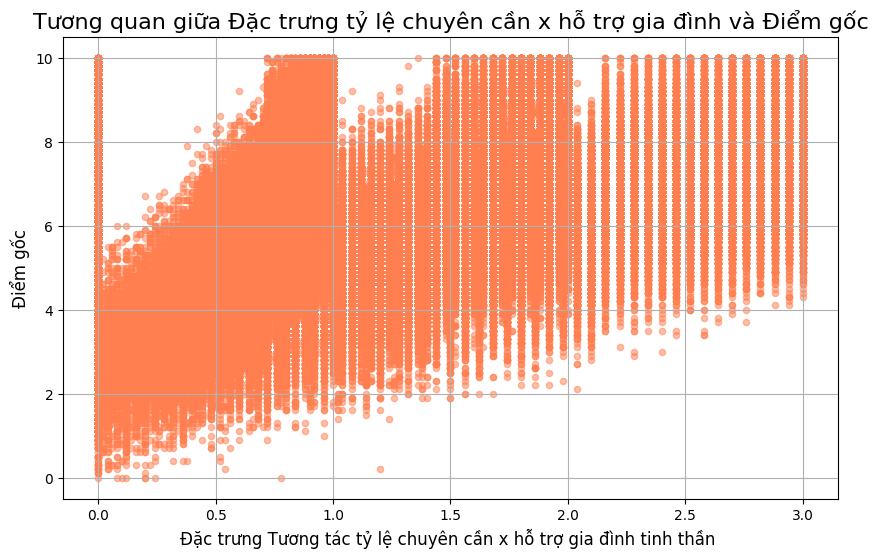

Đã lưu biểu đồ vào: plots_cleaned2_8_2025/points_interaction.png


In [35]:
df_featured.plot(kind='scatter', x='attendance_x_emotional_support', y='raw_score', alpha=0.5, figsize=(10, 6), c='coral')
plt.title('Tương quan giữa Đặc trưng tỷ lệ chuyên cần x hỗ trợ gia đình và Điểm gốc', fontsize=16)
plt.xlabel('Đặc trưng Tương tác tỷ lệ chuyên cần x hỗ trợ gia đình tinh thần ', fontsize=12)
plt.ylabel('Điểm gốc', fontsize=12)
plt.grid(True)

filepath = os.path.join(PLOTS_DIR, 'points_interaction.png')
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.show()
print(f"Đã lưu biểu đồ vào: {filepath}")

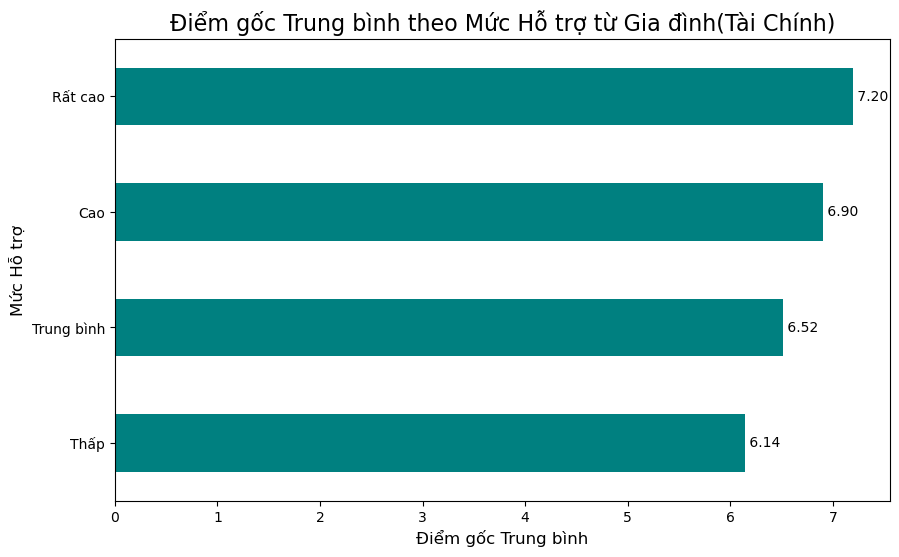

Đã lưu biểu đồ vào: plots_cleaned2_8_2025/avg_score_by_family_support.png


In [251]:
avg_score_by_support = df_featured.groupby('financial_support')['raw_score'].mean()
support_labels = {0: 'Thấp', 1: 'Trung bình', 2: 'Cao', 3: 'Rất cao'}
avg_score_by_support.index = avg_score_by_support.index.map(support_labels)
ax = avg_score_by_support.sort_values().plot(kind='barh', figsize=(10, 6), color='teal')
plt.title('Điểm gốc Trung bình theo Mức Hỗ trợ từ Gia đình(Tài Chính)', fontsize=16)
plt.xlabel('Điểm gốc Trung bình', fontsize=12)
plt.ylabel('Mức Hỗ trợ', fontsize=12)
for index, value in enumerate(avg_score_by_support.sort_values()):
    ax.text(value, index, f' {value:.2f}', va='center')

filepath = os.path.join(PLOTS_DIR, 'avg_score_by_family_support.png')
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.show()
print(f"Đã lưu biểu đồ vào: {filepath}")

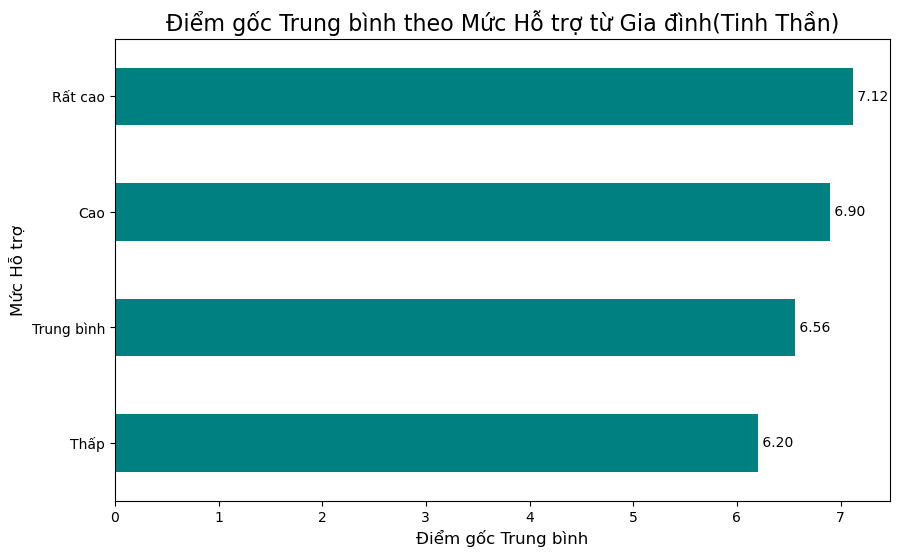

Đã lưu biểu đồ vào: plots_cleaned2_8_2025/avg_score_by_family_support.png


In [252]:
avg_score_by_support = df_featured.groupby('emotional_support')['raw_score'].mean()
support_labels = {0: 'Thấp', 1: 'Trung bình', 2: 'Cao', 3: 'Rất cao'}
avg_score_by_support.index = avg_score_by_support.index.map(support_labels)
ax = avg_score_by_support.sort_values().plot(kind='barh', figsize=(10, 6), color='teal')
plt.title('Điểm gốc Trung bình theo Mức Hỗ trợ từ Gia đình(Tinh Thần)', fontsize=16)
plt.xlabel('Điểm gốc Trung bình', fontsize=12)
plt.ylabel('Mức Hỗ trợ', fontsize=12)
for index, value in enumerate(avg_score_by_support.sort_values()):
    ax.text(value, index, f' {value:.2f}', va='center')

filepath = os.path.join(PLOTS_DIR, 'avg_score_by_family_support.png')
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.show()
print(f"Đã lưu biểu đồ vào: {filepath}")

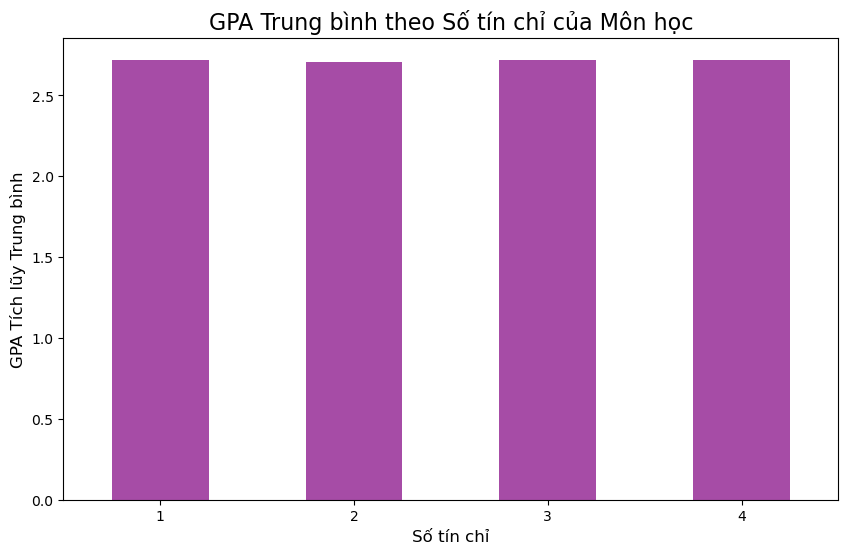

Đã lưu biểu đồ vào: plots_cleaned2_8_2025/avg_gpa_by_course_load.png


In [253]:
avg_gpa_by_credits = df_featured.groupby('credits_unit')['cumulative_gpa'].mean()
ax = avg_gpa_by_credits.plot(kind='bar', figsize=(10, 6), color='purple', alpha=0.7)
plt.title('GPA Trung bình theo Số tín chỉ của Môn học', fontsize=16)
plt.xlabel('Số tín chỉ', fontsize=12)
plt.ylabel('GPA Tích lũy Trung bình', fontsize=12)
plt.xticks(rotation=0)

filepath = os.path.join(PLOTS_DIR, 'avg_gpa_by_course_load.png')
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.show()
print(f"Đã lưu biểu đồ vào: {filepath}")

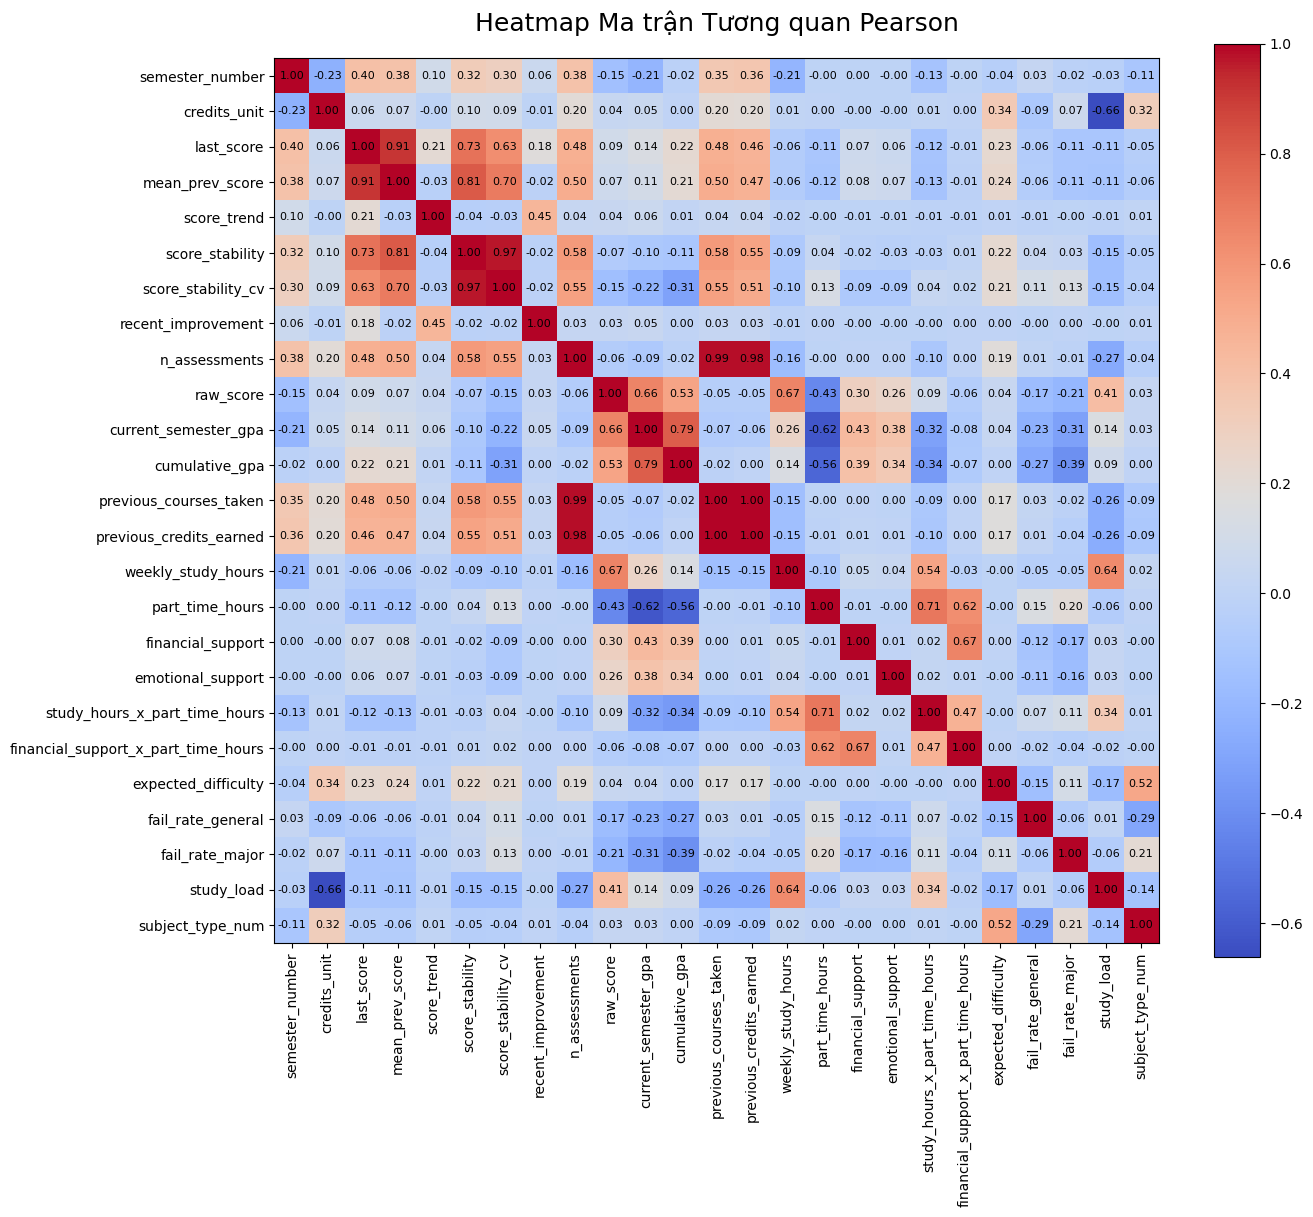

Đã lưu biểu đồ vào: plots_cleaned2_8_2025/correlation_heatmap.png


In [254]:
# Lấy các cột số để tính tương quan
numeric_df = df_featured.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 12))
cax = plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(cax)

# Thêm giá trị vào ô
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)

plt.title('Heatmap Ma trận Tương quan Pearson', fontsize=18, pad=20)
plt.xticks(ticks=np.arange(len(corr_matrix.columns)), labels=corr_matrix.columns, rotation=90)
plt.yticks(ticks=np.arange(len(corr_matrix.columns)), labels=corr_matrix.columns)
plt.tight_layout()

filepath = os.path.join(PLOTS_DIR, 'correlation_heatmap.png')
plt.savefig(filepath, dpi=150)
plt.show()
print(f"Đã lưu biểu đồ vào: {filepath}")

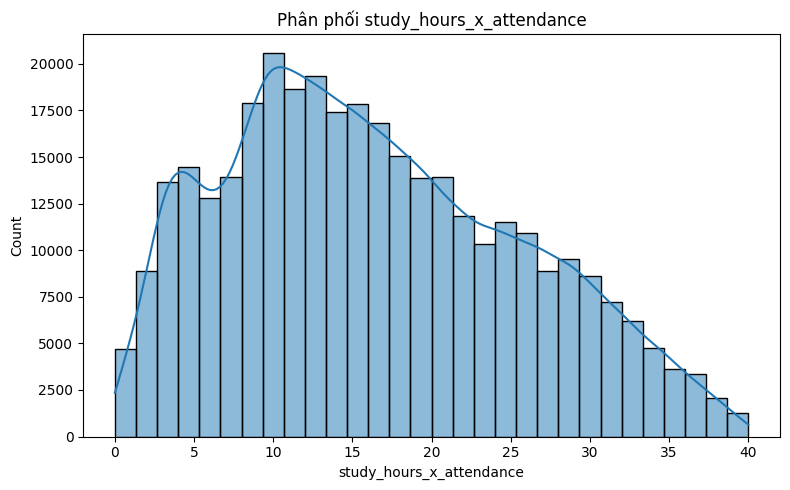

In [40]:
# Histogram: study_hours_x_attendance
plt.figure(figsize=(8, 5))
sns.histplot(df_featured['study_hours_x_attendance'], kde=True, bins=30)
plt.title('Phân phối study_hours_x_attendance')
plt.xlabel('study_hours_x_attendance')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'hist_study_hours_x_attendance.png'))
plt.show()

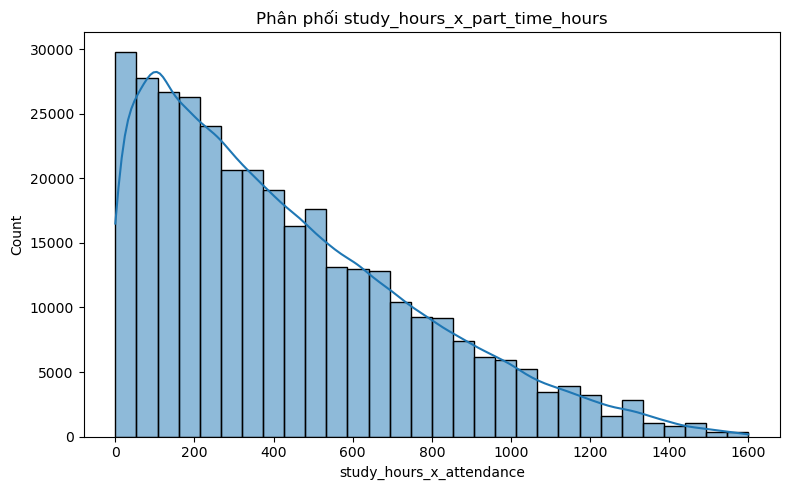

In [255]:
# Histogram: study_hours_x_attendance
plt.figure(figsize=(8, 5))
sns.histplot(df_featured['study_hours_x_part_time_hours'], kde=True, bins=30)
plt.title('Phân phối study_hours_x_part_time_hours')
plt.xlabel('study_hours_x_attendance')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'hist_study_hours_x_part_time_hours.png'))
plt.show()

In [256]:
# Boxplot: attendance_x_support theo subject_type
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_featured, x='subject_type', y='attendance_x_emotional_support')
plt.title('Attendance x Support theo Subject Type')
plt.xlabel('Subject Type (1=General, 2=Major)')
plt.ylabel('attendance_x_support')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'box_attendance_x_support_by_subject_type.png'))
plt.show()

ValueError: Could not interpret value `attendance_x_emotional_support` for `y`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

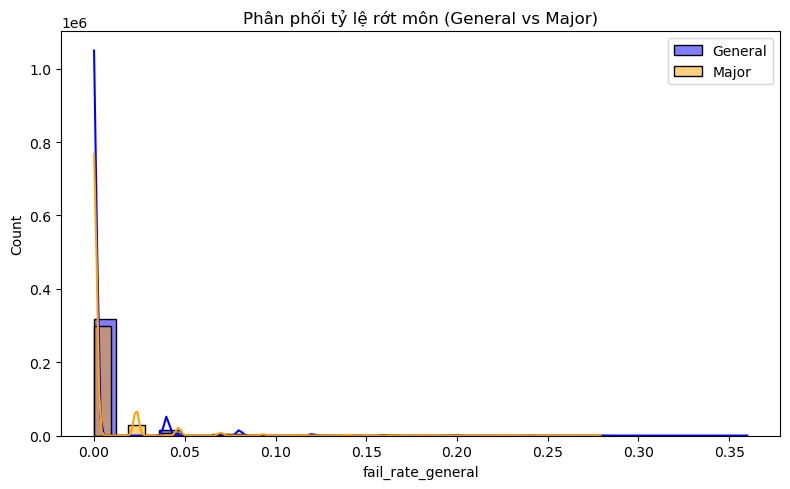

In [257]:
# Histogram: fail_rate_general vs fail_rate_major
plt.figure(figsize=(8, 5))
sns.histplot(df_featured['fail_rate_general'], color='blue', label='General', kde=True, bins=30)
sns.histplot(df_featured['fail_rate_major'], color='orange', label='Major', kde=True, bins=30)
plt.title('Phân phối tỷ lệ rớt môn (General vs Major)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'hist_fail_rate_general_vs_major.png'))
plt.show()

In [36]:
# # Histogram: attendance_gap_general_vs_major
# plt.figure(figsize=(8, 5))
# sns.histplot(df_featured['attendance_gap_general_vs_major'], kde=True, bins=30)
# plt.title('Chênh lệch chuyên cần General - Major')
# plt.xlabel('attendance_gap_general_vs_major')
# plt.tight_layout()
# plt.savefig(os.path.join(PLOTS_DIR, 'hist_attendance_gap.png'))
# plt.show()

In [39]:
# # Histogram: gpa_change_rate
# plt.figure(figsize=(8, 5))
# sns.histplot(df_featured['gpa_change_rate'].dropna(), kde=True, bins=30)
# plt.title('Phân phối gpa_change_rate')
# plt.xlabel('gpa_change_rate')
# plt.tight_layout()
# plt.savefig(os.path.join(PLOTS_DIR, 'hist_gpa_change_rate.png'))
# plt.show()